<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/An_EfficientNetV2B0%E2%80%93Transformer_Hybrid_Framework_for_Multi_Class_Skin_Lesion_Classification_on_the_PAD_UFES_20_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve

In [18]:
train_path = "/content/drive/MyDrive/SkinCancer_Split/train"
test_path = "/content/drive/MyDrive/SkinCancer_Split/test"

In [19]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [20]:
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input
)

In [21]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes

print(train_generator.class_indices)
print("Number of classes:", NUM_CLASSES)

Found 1838 images belonging to 6 classes.
Found 460 images belonging to 6 classes.
{'ACK': 0, 'BCC': 1, 'MEL': 2, 'NEV': 3, 'SCC': 4, 'SEK': 5}
Number of classes: 6


In [22]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.5245433789954338), 1: np.float64(0.4531558185404339), 2: np.float64(7.2936507936507935), 3: np.float64(1.570940170940171), 4: np.float64(2.002178649237473), 5: np.float64(1.6294326241134751)}


In [23]:
def transformer_block(x, num_heads=4):

    c = x.shape[-1]

    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=c // 4
    )(x, x)

    x1 = layers.Add()([x, attn])
    x1 = layers.LayerNormalization()(x1)

    ffn = layers.Dense(c * 2, activation='gelu')(x1)
    ffn = layers.Dense(c)(ffn)

    x2 = layers.Add()([x1, ffn])
    x2 = layers.LayerNormalization()(x2)

    return x2

In [24]:
def build_model(num_classes):

    inputs = layers.Input(shape=(224,224,3))

    # EfficientNetV2B0 backbone
    base = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )

    # Fine-tune last 80 layers
    base.trainable = True

    for layer in base.layers[:-80]:
        layer.trainable = False

    x = base.output

    # Feature map dimensions
    h, w, c = x.shape[1], x.shape[2], x.shape[3]

    patches = h * w

    # Convert feature map to sequence
    x = layers.Reshape((patches, c))(x)

    # Positional embedding
    pos = tf.range(start=0, limit=patches, delta=1)

    pos_emb = layers.Embedding(
        input_dim=patches,
        output_dim=c
    )(pos)

    x = x + pos_emb

    # Transformer Encoder Block 1
    x = transformer_block(x)

    # Transformer Encoder Block 2
    x = transformer_block(x)

    # Global pooling
    x = layers.GlobalAveragePooling1D()(x)

    # Classification head
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        num_classes,
        activation='softmax'
    )(x)

    model = models.Model(inputs, outputs)

    return model

In [25]:
model = build_model(NUM_CLASSES)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          0 │ rescaling_1[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 32,950,614 (125.70 MB)

 Trainable params: 30,127,222 (114.93 MB)

 Non-trainable params: 2,823,392 (10.77 MB)

In [26]:
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        verbose=1
    ),

    ModelCheckpoint(
        "best_PAD_UFES20_model.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [28]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.2798 - loss: 1.9146 
Epoch 1: val_accuracy improved from None to 0.46522, saving model to best_PAD_UFES20_model.keras

Epoch 1: finished saving model to best_PAD_UFES20_model.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 699s 12s/step - accuracy: 0.3379 - loss: 1.8341 - val_accuracy: 0.4652 - val_loss: 1.2761 - learning_rate: 3.0000e-04
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.4595 - loss: 1.5054 
Epoch 2: val_accuracy improved from 0.46522 to 0.62391, saving model to best_PAD_UFES20_model.keras

Epoch 2: finished saving model to best_PAD_UFES20_model.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 695s 12s/step - accuracy: 0.4559 - loss: 1.5503 - val_accuracy: 0.6239 - val_loss: 1.0952 - learning_rate: 3.0000e-04
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.5107 - loss: 1.2463 
Epoch 3: val_accuracy did not improve from 0.62391
58/58 ━━━━━━━━━━━━━━━━━━━━ 649s 11s/step - accuracy: 0.5131 - loss: 1.2359 - val_

In [29]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss :", round(loss,4))
print("Test Accuracy :", round(accuracy*100,2), "%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.6435 - loss: 0.9266
Test Loss : 0.9266
Test Accuracy : 64.35 %


In [ ]:
y_pred_prob = model.predict(test_generator)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

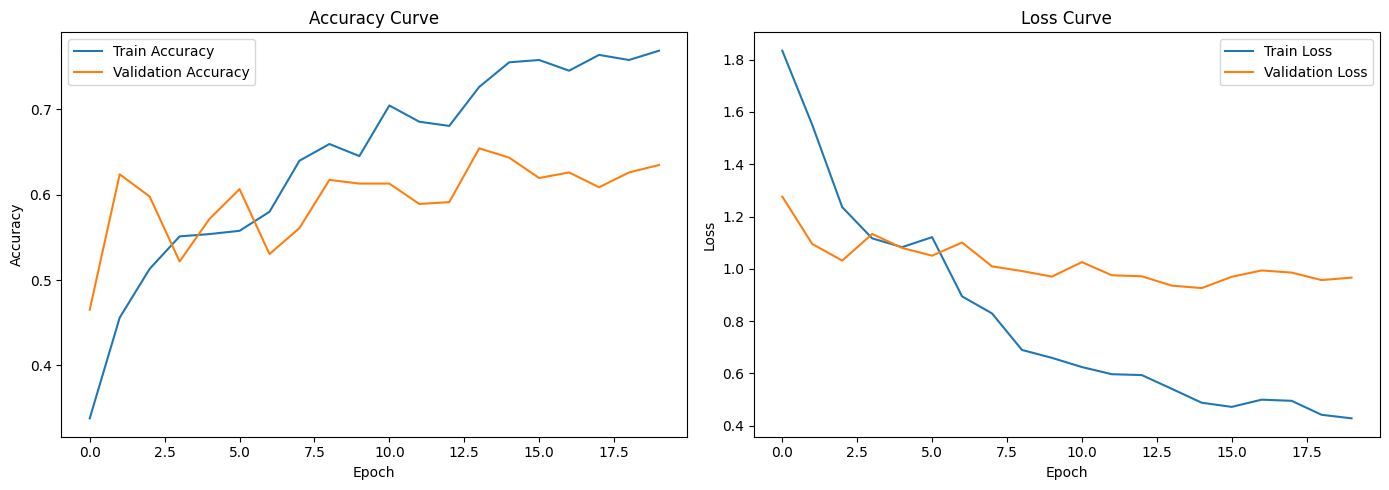

In [31]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [33]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

         ACK       0.74      0.72      0.73       146
         BCC       0.75      0.59      0.66       169
         MEL       0.58      0.70      0.64        10
         NEV       0.66      0.84      0.74        49
         SCC       0.21      0.38      0.27        39
         SEK       0.70      0.60      0.64        47

    accuracy                           0.64       460
   macro avg       0.61      0.64      0.61       460
weighted avg       0.68      0.64      0.66       460



In [34]:
precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")

Precision : 68.35%
Recall    : 64.35%
F1 Score  : 65.62%


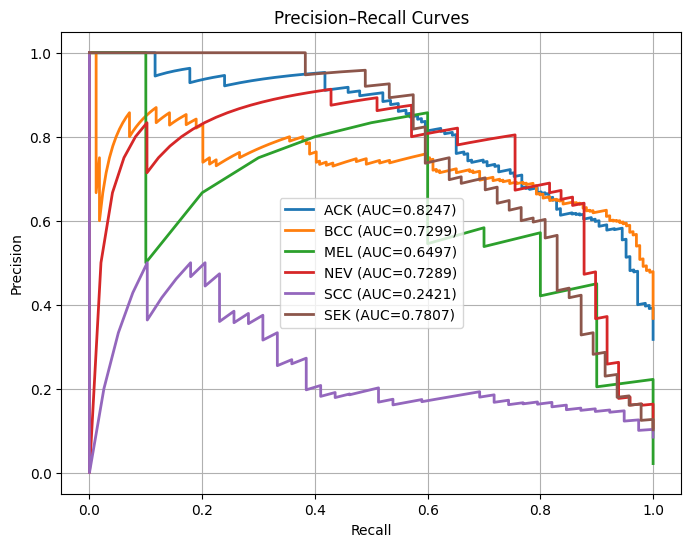

In [35]:
# Binarize labels
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(len(class_names))
)

plt.figure(figsize=(8,6))

pr_auc = {}

for i in range(len(class_names)):

    precision_curve, recall_curve, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_pred_prob[:, i]
    )

    pr_auc[i] = auc(recall_curve, precision_curve)

    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f'{class_names[i]} (AUC={pr_auc[i]:.4f})'
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.grid()

plt.show()

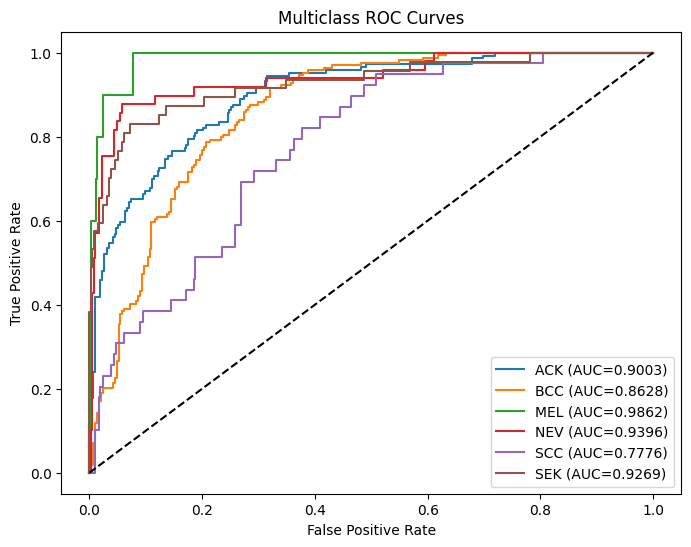

In [36]:
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(len(class_names))
)

plt.figure(figsize=(8,6))

roc_auc = {}

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:,i],
        y_pred_prob[:,i]
    )

    roc_auc[i] = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{class_names[i]} (AUC={roc_auc[i]:.4f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves")
plt.legend()
plt.show()

In [37]:
print("AUC Values")

for i in range(len(class_names)):
    print(
        f"{class_names[i]} : {roc_auc[i]:.4f}"
    )

AUC Values
ACK : 0.9003
BCC : 0.8628
MEL : 0.9862
NEV : 0.9396
SCC : 0.7776
SEK : 0.9269


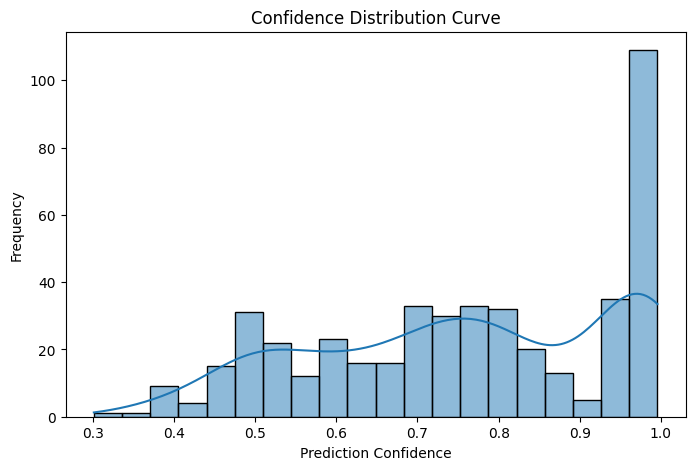

In [38]:
confidence = np.max(
    y_pred_prob,
    axis=1
)

plt.figure(figsize=(8,5))

sns.histplot(
    confidence,
    bins=20,
    kde=True
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution Curve")

plt.show()